# STEP-1 Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

#Visualization Libraries 
import matplotlib.pyplot as plt
import seaborn as sns

#Machine Learning Libraries 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree

# STEP-2 Load Dataset

In [2]:
df = pd.read_csv("DECISION TREE_Social_Network_Ads.csv")
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


# STEP-3 Basic Information About Dataset

In [3]:
print("Shape of Dataset:")
print(df.shape)

Shape of Dataset:
(400, 5)


In [4]:
print("Columns:")
print(df.columns)

Columns:
Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')


In [5]:
print("Dataset Info:")
print(df.info())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB
None


In [6]:
print("Null Values:")
print(df.isnull().sum())

Null Values:
User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64


# STEP-4 Check Duplicate Values

In [7]:
print("Duplicate Rows :", df.duplicated().sum())

Duplicate Rows : 0


# STEP-5 Encode Gender Column

In [8]:
le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

# Male = 1
# Female = 0

print(df.head())

    User ID  Gender  Age  EstimatedSalary  Purchased
0  15624510       1   19            19000          0
1  15810944       1   35            20000          0
2  15668575       0   26            43000          0
3  15603246       0   27            57000          0
4  15804002       1   19            76000          0


# STEP-6 Feature Selection

In [9]:
X = df[['Gender', 'Age', 'EstimatedSalary']]

y = df['Purchased']

print(X.head())
print(y.head())

   Gender  Age  EstimatedSalary
0       1   19            19000
1       1   35            20000
2       0   26            43000
3       0   27            57000
4       1   19            76000
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


# STEP-7 Train Test Split

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (320, 3)
Testing Data Shape: (80, 3)


# STEP-8 Create Decision Tree Model

In [11]:
model = DecisionTreeClassifier(
    criterion = 'entropy',
    random_state = 42,
    max_depth = 5
)

#Train Model
model.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)

# STEP-9 Model Prediction

In [12]:
y_pred = model.predict(X_test)

print("Predicted Values:")

print(y_pred)

Predicted Values:
[1 1 0 1 0 0 1 0 0 0 0 1 0 0 0 1 1 1 0 1 0 0 1 1 0 1 0 0 1 0 0 0 1 0 1 0 0
 0 0 0 1 0 0 1 0 1 0 0 0 0 0 1 0 0 0 0 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 0 0 0
 1 0 1 1 0 0]


# STEP-10 Accuracy Score

In [13]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", accuracy)

Accuracy Score: 0.9125


# STEP-11 Confusion Matrix

In [14]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[48  4]
 [ 3 25]]


# STEP-12 Classification Report

In [15]:
report = classification_report(y_test, y_pred)

print(report)

              precision    recall  f1-score   support

           0       0.94      0.92      0.93        52
           1       0.86      0.89      0.88        28

    accuracy                           0.91        80
   macro avg       0.90      0.91      0.90        80
weighted avg       0.91      0.91      0.91        80



# STEP-13 Visualize Confusion Matrix

Text(45.722222222222214, 0.5, 'Actual')

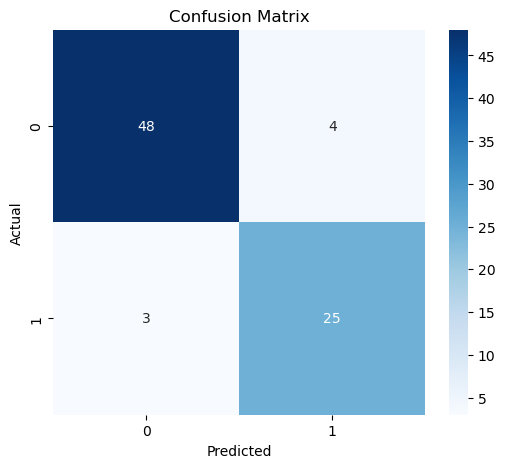

In [16]:
plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues'
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

# STEP-14 Feature Importance

In [17]:
importance = model.feature_importances_

feature_names = X.columns

#Create DataFrame
importance_df = pd.DataFrame({
    'Feature' : feature_names,
    'Importance' : importance
})

print(importance_df)

           Feature  Importance
0           Gender    0.000000
1              Age    0.434246
2  EstimatedSalary    0.565754


# STEP-15 Feature Importance Graph

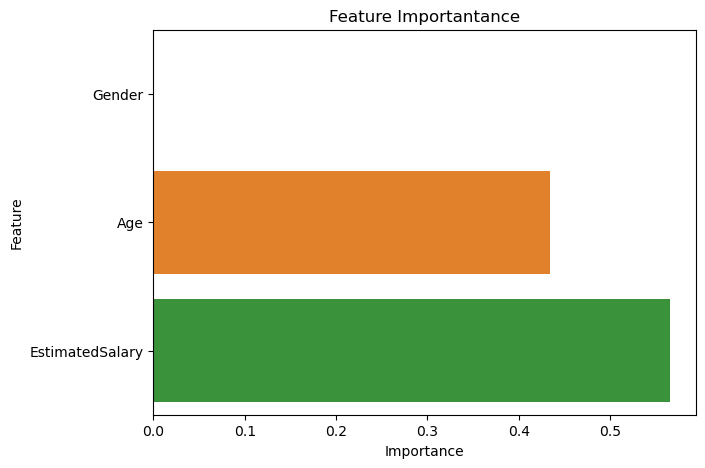

In [18]:
plt.figure(figsize = (7,5))

sns.barplot(
    x = 'Importance',
    y = 'Feature',
    data = importance_df
)

plt.title("Feature Importantance")
plt.show()

# STEP-16 Decision Tree Visualization

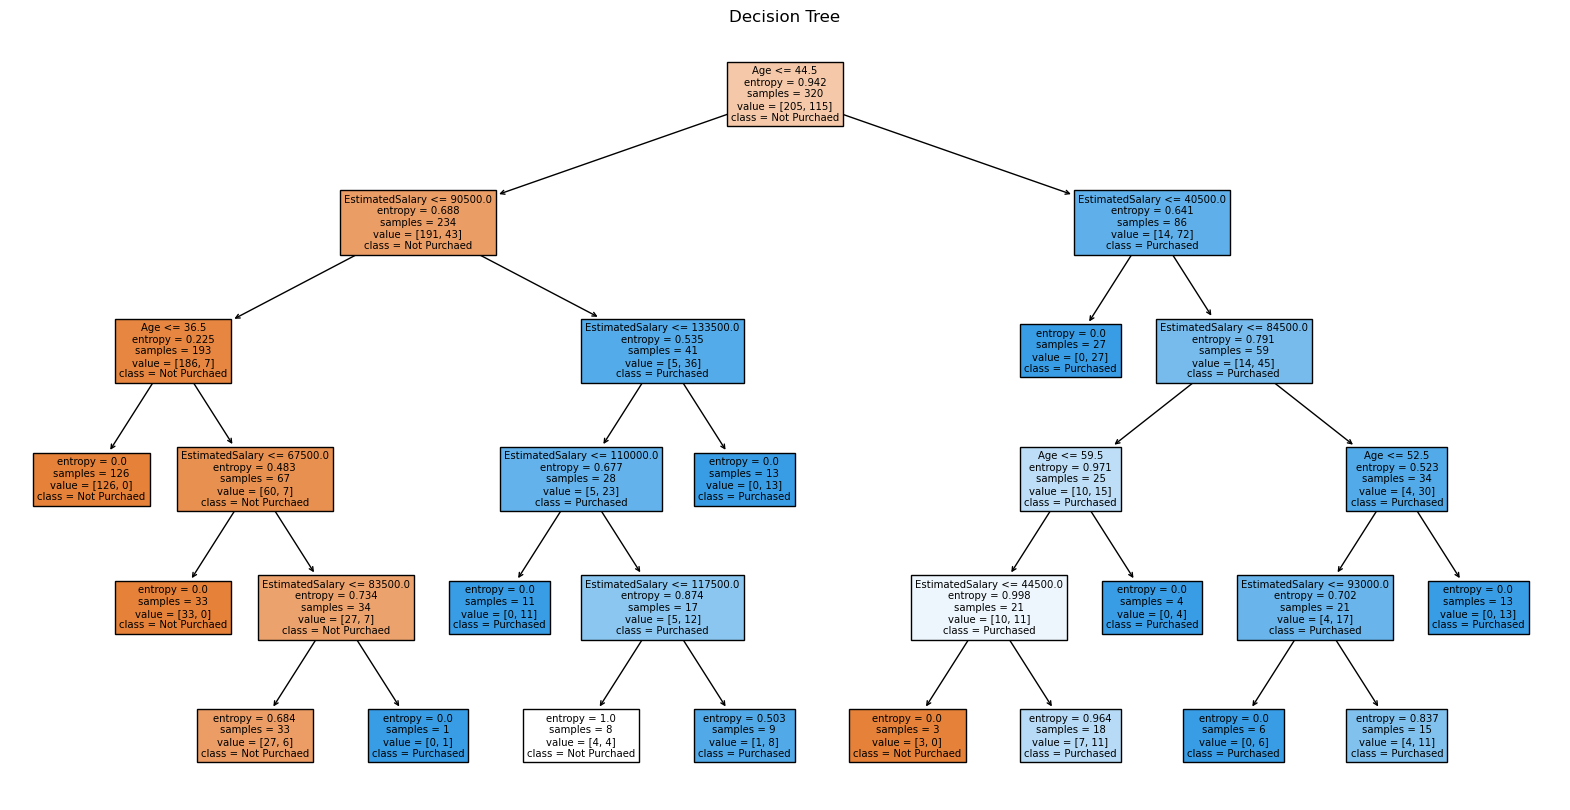

In [19]:
plt.figure(figsize = (20,10))

tree.plot_tree(
    model,
    feature_names = X.columns,
    class_names = ['Not Purchaed', 'Purchased'],
    filled = True
)

plt.title("Decision Tree")

plt.show()

# STEP-17 Predict New Customer Data

In [20]:
# Gender = Male = 1
# Age = 30
# EstimatedSalary = 87000


new_data = [[1, 30, 87000]]

prediction = model.predict(new_data)

if prediction[0] == 1:
    print("Customer Will Purchase")
    
else:
    print("Customer will NOT Purchase")

Customer will NOT Purchase


C:\Users\vidhu\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
